<a href="https://colab.research.google.com/github/AndreiAf02/Data-Balancing-in-ML-DNN/blob/main/CIFAR_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import seaborn as sns
import pandas as pd

In [ ]:
path_to_data2 = 'https://raw.githubusercontent.com/AndreiAf02/Data-Balancing-in-ML-DNN/main/'

In [ ]:
def perf_metrics(data, label):
    data_len = len(data)
    # print('Number of iterations:', data_len)
    mean = np.mean(data[label])
    var = np.var(data[label], ddof=1)
    var_mean = var/data_len

    se_mean = np.sqrt(var_mean)
    error_bound = 1.96*se_mean
    CI_low = mean - error_bound
    CI_high = mean + error_bound

    print('Error type:', label)
    print('Mean:', mean)
    print('Variance:', var)
    print('Variance of estimate:', var_mean)
    print('Standard error:', se_mean)
    print('95% Confidence Interval:  [', CI_low, ', ', CI_high, ']')
    print('-----------------------------')


Loading the performance data for the six sampling methods (plus original imbalanced data) collected from fine-tuning:

In [ ]:
data_orig = pd.read_csv(path_to_data2+"CIFAR_Fine_Tuning_Imbalanced.csv", sep=",", header=0)
data_SRS = pd.read_csv(path_to_data2+"CIFAR_SRS_Fine_Tuning.csv", sep=",", header=0)
data_SRSwR = pd.read_csv(path_to_data2+"CIFAR_SRSwR_Fine_Tuning.csv", sep=",", header=0)
data_Sy = pd.read_csv(path_to_data2+"CIFAR_Sy_Fine_Tuning.csv", sep=",", header=0)
data_Sym = pd.read_csv(path_to_data2+"CIFAR_Sy_multi_Fine_Tuning.csv", sep=",", header=0)
data_SRS_ROS = pd.read_csv(path_to_data2+"CIFAR_SRS_ROS_Fine_Tuning.csv", sep=",", header=0)
data_Sy_ROS = pd.read_csv(path_to_data2+"CIFAR_Sy_ROS_Fine_Tuning.csv", sep=",", header=0)



# data_orig

Original (imbalanced) data performance:

In [ ]:
data_orig

,Unnamed: 0,FPR,FNR
0,0,0.108,0.700
1,1,0.096,0.726
2,2,0.100,0.732
3,3,0.083,0.766
4,4,0.098,0.718
5,5,0.089,0.760
6,6,0.083,0.764
7,7,0.093,0.740
8,8,0.101,0.732
9,9,0.084,0.772


Error type: FPR
Mean: 0.08285999999999999
Variance: 0.00025575551020408165
Variance of estimate: 5.115110204081633e-06
Standard error: 0.002261660939239486
95% Confidence Interval:  [ 0.0784271445590906 ,  0.08729285544090938 ]
-----------------------------
Error type: FNR
Mean: 0.76304
Variance: 0.0012805289795918375
Variance of estimate: 2.561057959183675e-05
Standard error: 0.005060689635991991
95% Confidence Interval:  [ 0.7531210483134557 ,  0.7729589516865444 ]
-----------------------------


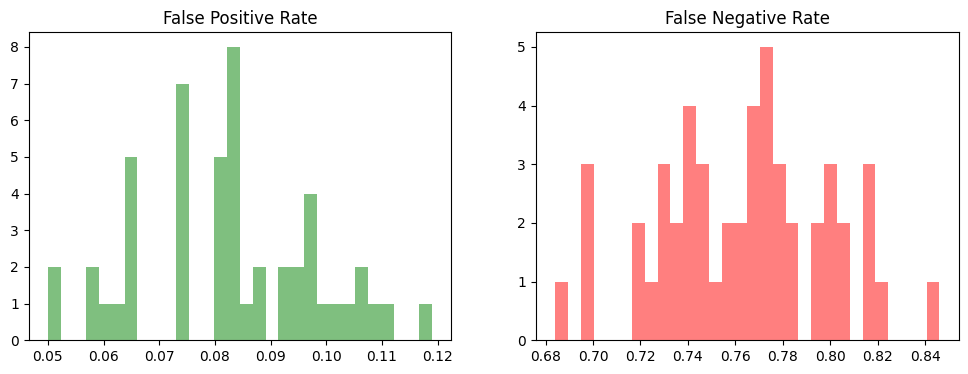

In [ ]:
data = data_orig

orig_FPR = data['FPR']
orig_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

## Random Undersampling (RUS):

SRS Random Undersampling performance:

Error type: FPR
Mean: 0.32516
Variance: 0.0007018731313131318
Variance of estimate: 7.018731313131318e-06
Standard error: 0.0026492888315793953
95% Confidence Interval:  [ 0.31996739389010437 ,  0.33035260610989564 ]
-----------------------------
Error type: FNR
Mean: 0.5025200000000001
Variance: 0.0005073632323232329
Variance of estimate: 5.073632323232329e-06
Standard error: 0.002252472491115558
95% Confidence Interval:  [ 0.49810515391741356 ,  0.5069348460825865 ]
-----------------------------


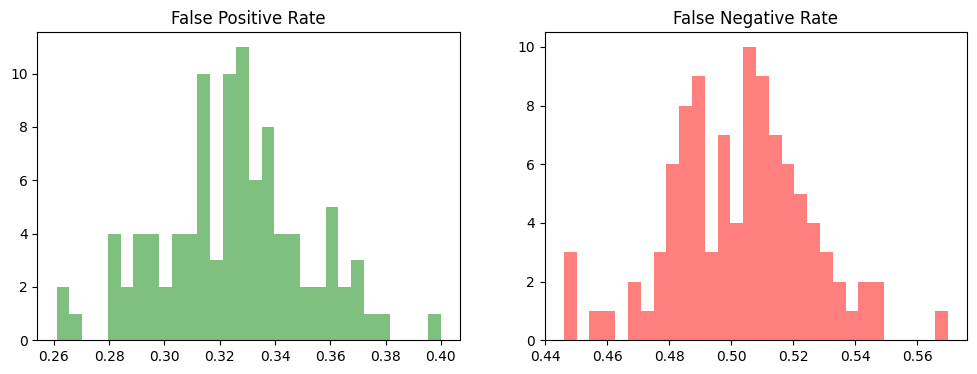

In [ ]:
data = data_SRS

SRS_FPR = data['FPR']
SRS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

SRSwR undersampling performance:

Error type: FPR
Mean: 0.36408
Variance: 0.0007174884848484848
Variance of estimate: 7.174884848484847e-06
Standard error: 0.0026785975525421596
95% Confidence Interval:  [ 0.3588299487970174 ,  0.3693300512029826 ]
-----------------------------
Error type: FNR
Mean: 0.50562
Variance: 0.000419046060606061
Variance of estimate: 4.19046060606061e-06
Standard error: 0.0020470614563467826
95% Confidence Interval:  [ 0.5016077595455603 ,  0.5096322404544397 ]
-----------------------------


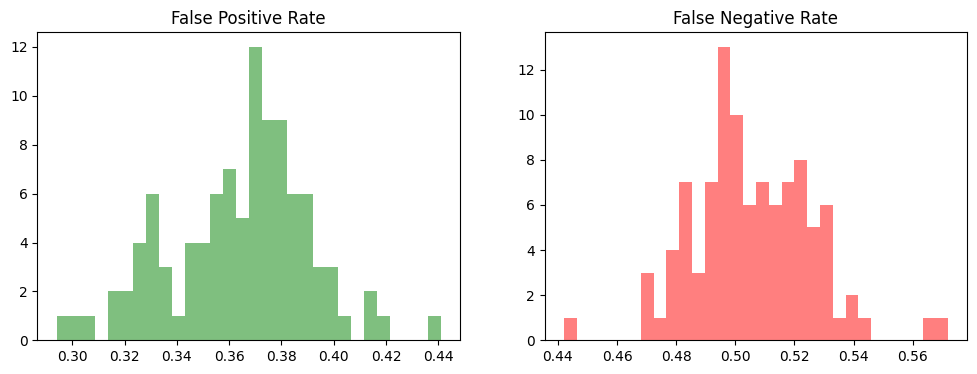

In [ ]:
data = data_SRSwR

SRSwR_FPR = data['FPR']
SRSwR_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Undersampling performance:

Error type: FPR
Mean: 0.32159000000000004
Variance: 0.000548385757575758
Variance of estimate: 5.4838575757575796e-06
Standard error: 0.002341763774542082
95% Confidence Interval:  [ 0.31700014300189755 ,  0.32617985699810254 ]
-----------------------------
Error type: FNR
Mean: 0.5182800000000001
Variance: 0.0005527288888888893
Variance of estimate: 5.527288888888893e-06
Standard error: 0.002351018691735328
95% Confidence Interval:  [ 0.5136720033641988 ,  0.5228879966358013 ]
-----------------------------


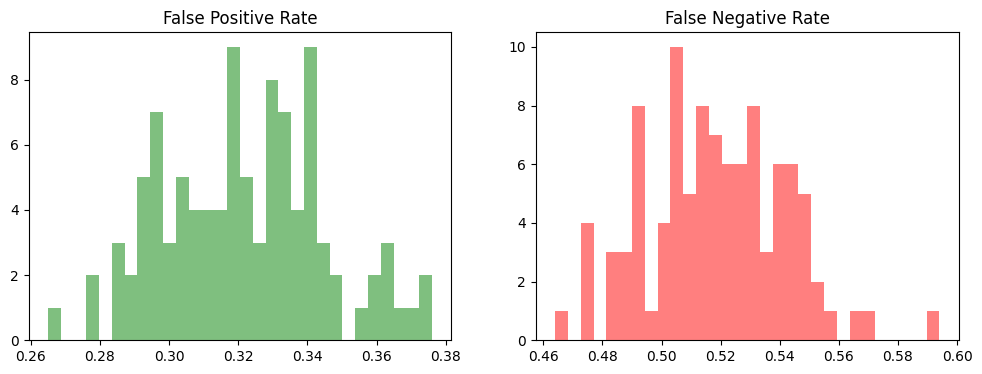

In [ ]:
data = data_Sy

Sy_FPR = data['FPR']
Sy_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Multiple Systematic undersampling performance:

Error type: FPR
Mean: 0.35247
Variance: 0.0005110798989898989
Variance of estimate: 5.110798989898989e-06
Standard error: 0.002260707630344753
95% Confidence Interval:  [ 0.3480390130445243 ,  0.35690098695547573 ]
-----------------------------
Error type: FNR
Mean: 0.51154
Variance: 0.0006252812121212126
Variance of estimate: 6.252812121212127e-06
Standard error: 0.002500562360992448
95% Confidence Interval:  [ 0.5066388977724547 ,  0.5164411022275452 ]
-----------------------------


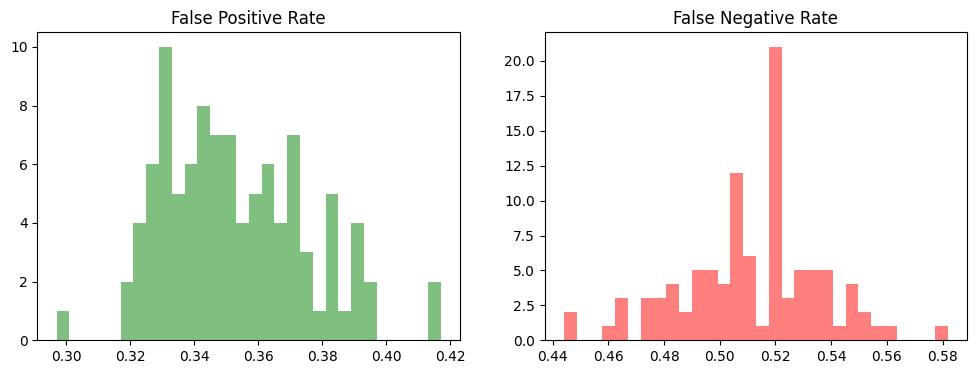

In [ ]:
data = data_Sym

Sym_FPR = data['FPR']
Sym_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

## Random Oversampling (ROS):

SRS Oversampling performance:

Error type: FPR
Mean: 0.3810300000000001
Variance: 0.000500049595959596
Variance of estimate: 5.000495959595961e-06
Standard error: 0.0022361788746868977
95% Confidence Interval:  [ 0.37664708940561376 ,  0.3854129105943864 ]
-----------------------------
Error type: FNR
Mean: 0.49252
Variance: 0.0006138682828282833
Variance of estimate: 6.138682828282833e-06
Standard error: 0.0024776365407950442
95% Confidence Interval:  [ 0.48766383238004174 ,  0.4973761676199583 ]
-----------------------------


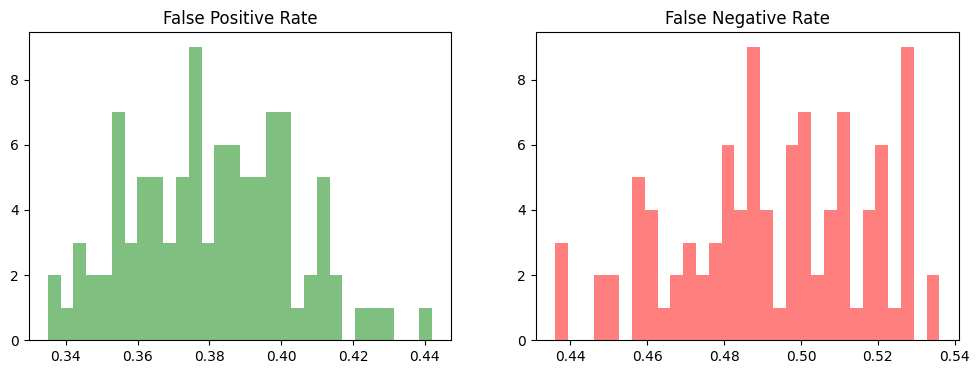

In [ ]:
data = data_SRS_ROS

SRS_ROS_FPR = data['FPR']
SRS_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Resampling performance:

Error type: FPR
Mean: 0.37902
Variance: 0.0005094137373737378
Variance of estimate: 5.094137373737378e-06
Standard error: 0.0022570195776149965
95% Confidence Interval:  [ 0.37459624162787464 ,  0.3834437583721254 ]
-----------------------------
Error type: FNR
Mean: 0.5111000000000001
Variance: 0.001158818181818182
Variance of estimate: 1.1588181818181821e-05
Standard error: 0.0034041418622292787
95% Confidence Interval:  [ 0.5044278819500307 ,  0.5177721180499695 ]
-----------------------------


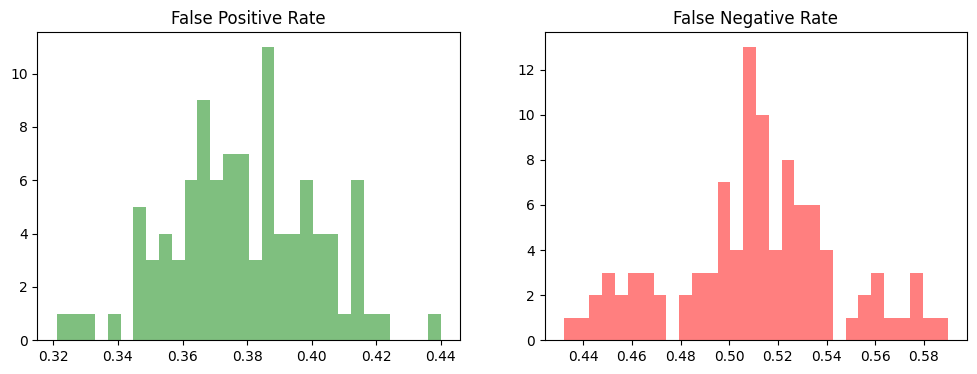

In [ ]:
data = data_Sy_ROS

Sy_ROS_FPR = data['FPR']
Sy_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

In [ ]:
FPR = pd.DataFrame()

DF = FPR


DF['SRS_RUS'] = SRS_FPR
DF['SRSwR_RUS'] = SRSwR_FPR
DF['Sy_RUS'] = Sy_FPR
DF['Sy_m_RUS'] = Sym_FPR
DF['SRS_ROS'] = SRS_ROS_FPR
DF['Sy_ROS'] = Sy_ROS_FPR
DF['Orig'] = orig_FPR
FPR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.324,0.379,0.321,0.337,0.383,0.360,0.108
1,0.314,0.379,0.330,0.335,0.390,0.358,0.096
2,0.292,0.362,0.284,0.341,0.395,0.380,0.100
3,0.360,0.355,0.330,0.349,0.396,0.354,0.083
4,0.345,0.360,0.359,0.336,0.402,0.365,0.098
...,...,...,...,...,...,...,...
95,0.283,0.365,0.298,0.332,0.376,0.377,NaN
96,0.285,0.329,0.315,0.321,0.381,0.402,NaN
97,0.301,0.351,0.335,0.416,0.362,0.388,NaN
98,0.281,0.363,0.297,0.381,0.389,0.368,NaN


<Axes: title={'center': 'FPR'}>

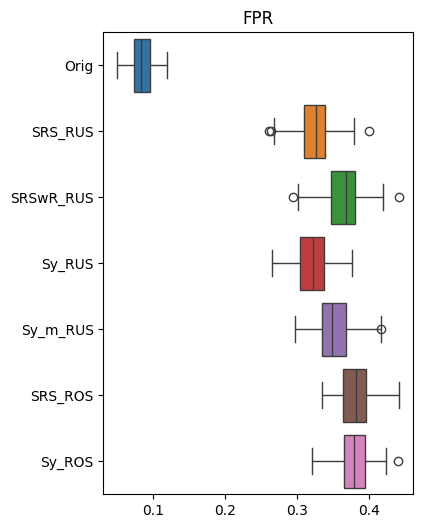

In [ ]:
dataset = FPR

plt.figure(figsize=(4,6)) #, dpi=600)
plt.title('FPR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')

In [ ]:
FNR = pd.DataFrame()

DF = FNR


DF['SRS_RUS'] = SRS_FNR
DF['SRSwR_RUS'] = SRSwR_FNR
DF['Sy_RUS'] = Sy_FNR
DF['Sy_m_RUS'] = Sym_FNR
DF['SRS_ROS'] = SRS_ROS_FNR
DF['Sy_ROS'] = Sy_ROS_FNR
DF['Orig'] = orig_FNR
FNR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.506,0.502,0.550,0.522,0.520,0.516,0.700
1,0.504,0.504,0.540,0.518,0.502,0.516,0.726
2,0.522,0.516,0.594,0.522,0.502,0.510,0.732
3,0.488,0.526,0.540,0.508,0.502,0.530,0.766
4,0.484,0.516,0.512,0.522,0.484,0.506,0.718
...,...,...,...,...,...,...,...
95,0.520,0.500,0.538,0.546,0.502,0.510,NaN
96,0.512,0.536,0.506,0.562,0.486,0.492,NaN
97,0.488,0.524,0.494,0.464,0.516,0.510,NaN
98,0.522,0.512,0.528,0.490,0.478,0.526,NaN


<Axes: title={'center': 'FNR'}>

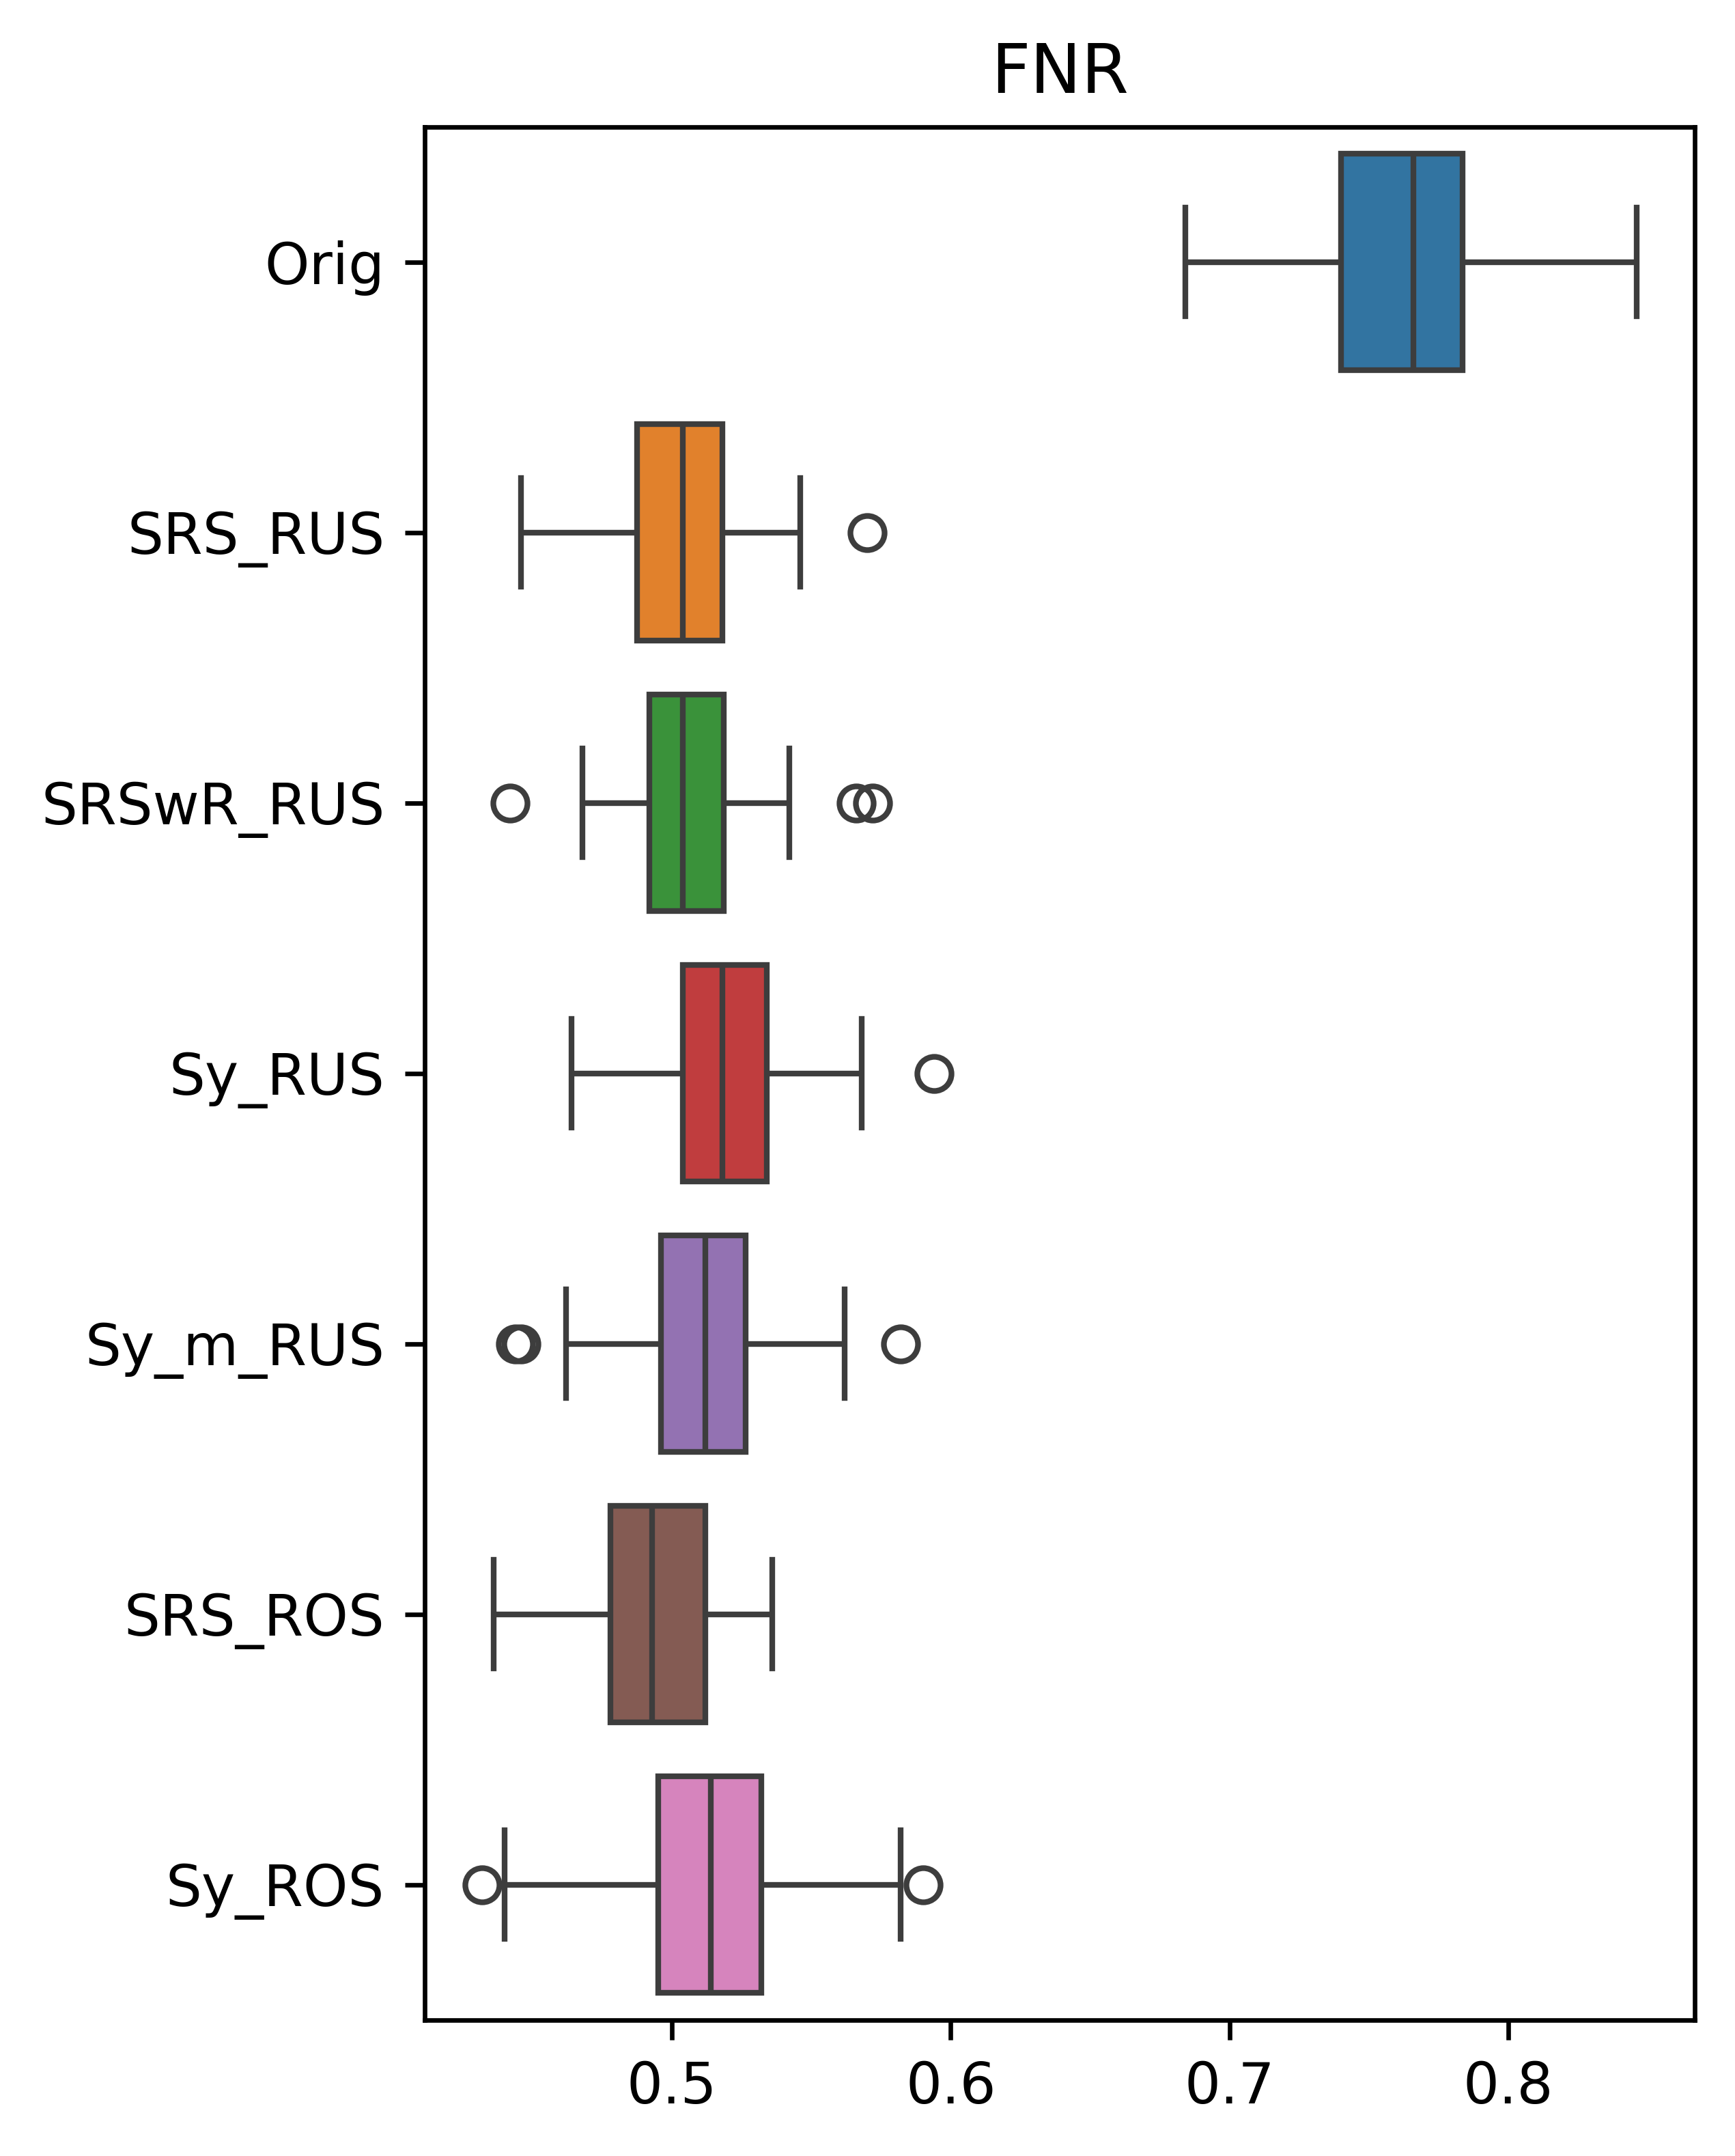

In [ ]:
dataset = FNR

plt.figure(figsize=(4,6), dpi=600)
plt.title('FNR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')

## Machine Learning Classification performance:

In [ ]:
data_orig = pd.read_csv(path_to_data2+"CIFAR_ML_Imbalanced.csv", sep=",", header=0)
data_SRS = pd.read_csv(path_to_data2+"CIFAR_ML_SRS_RUS.csv", sep=",", header=0)
data_SRSwR = pd.read_csv(path_to_data2+"CIFAR_ML_SRSwR_RUS.csv", sep=",", header=0)
data_Sy = pd.read_csv(path_to_data2+"CIFAR_ML_Sy_RUS.csv", sep=",", header=0)
data_Sy2 = pd.read_csv(path_to_data2+"CIFAR_ML_Sy2_RUS.csv", sep=",", header=0)
data_SRS_ROS = pd.read_csv(path_to_data2+"CIFAR_ML_SRS_ROS2.csv", sep=",", header=0)
data_Sy_ROS = pd.read_csv(path_to_data2+"CIFAR_ML_Sy_ROS2_20.csv", sep=",", header=0)

data_SRS

,Unnamed: 0,FPR,TPR,FNR,TNR
0,0,0.172667,0.667,0.333,0.827333
1,1,0.085667,0.535,0.465,0.914333
2,2,0.188667,0.709,0.291,0.811333
3,3,0.124000,0.547,0.453,0.876000
4,4,0.130000,0.659,0.341,0.870000
...,...,...,...,...,...
95,95,0.114000,0.613,0.387,0.886000
96,96,0.187333,0.702,0.298,0.812667
97,97,0.056333,0.481,0.519,0.943667
98,98,0.154000,0.702,0.298,0.846000


Original (imbalanced) dataset:

In [ ]:
print('SRS RUS', len(data_SRS))
print('SRSwR RUS', len(data_SRSwR))
print('Sy RUS', len(data_Sy))
print('Sym RUS', len(data_Sy2))
print('SRS ROS', len(data_SRS_ROS))
print('Sy ROS', len(data_Sy_ROS))



SRS RUS 100
SRSwR RUS 100
Sy RUS 100
Sym RUS 100
SRS ROS 100
Sy ROS 100


In [ ]:
orig_FPR = data_orig['FPR']
orig_FNR = data_orig['FNR']


Error type: FPR
Mean: 0.007619999999999969
Variance: 2.4435419501133733e-05
Variance of estimate: 4.887083900226747e-07
Standard error: 0.0006990768126770296
95% Confidence Interval:  [ 0.006249809447152991 ,  0.008990190552846947 ]
-----------------------------
Error type: FNR
Mean: 0.8010800000000002
Variance: 0.00427032
Variance of estimate: 8.54064e-05
Standard error: 0.009241558310155273
95% Confidence Interval:  [ 0.7829665457120959 ,  0.8191934542879046 ]
-----------------------------


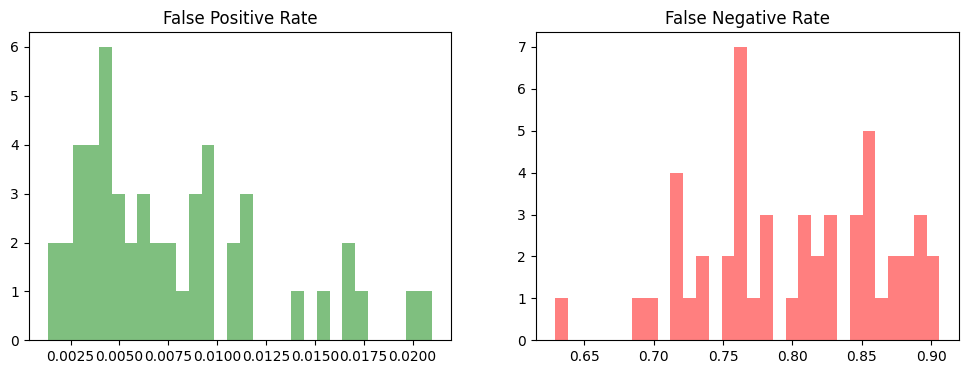

In [ ]:
data = data_orig

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

##Random Undersampling (RUS):

SRS undersampling performance:

Error type: FPR
Mean: 0.13546999999999995
Variance: 0.0034607880920314252
Variance of estimate: 3.460788092031425e-05
Standard error: 0.005882846328123339
95% Confidence Interval:  [ 0.12393962119687821 ,  0.1470003788031217 ]
-----------------------------
Error type: FNR
Mean: 0.3788500000000001
Variance: 0.006205260101010103
Variance of estimate: 6.205260101010103e-05
Standard error: 0.00787734733334141
95% Confidence Interval:  [ 0.3634103992266509 ,  0.39428960077334924 ]
-----------------------------


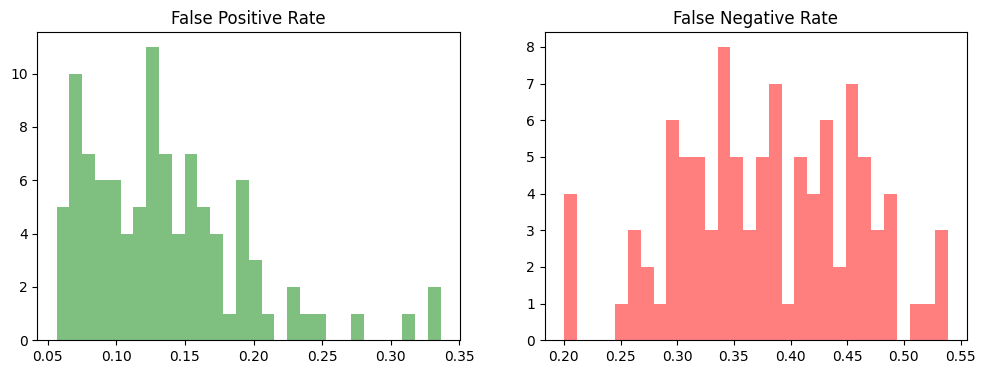

In [ ]:
data = data_SRS

SRS_FPR = data['FPR']
SRS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

SRSwR Undersampling performance:

Error type: FPR
Mean: 0.12687999999999997
Variance: 0.0039750045342312
Variance of estimate: 3.9750045342312e-05
Standard error: 0.006304763702337464
95% Confidence Interval:  [ 0.11452266314341854 ,  0.1392373368565814 ]
-----------------------------
Error type: FNR
Mean: 0.39992000000000005
Variance: 0.008355225858585861
Variance of estimate: 8.35522585858586e-05
Standard error: 0.00914069245658438
95% Confidence Interval:  [ 0.38200424278509465 ,  0.41783575721490546 ]
-----------------------------


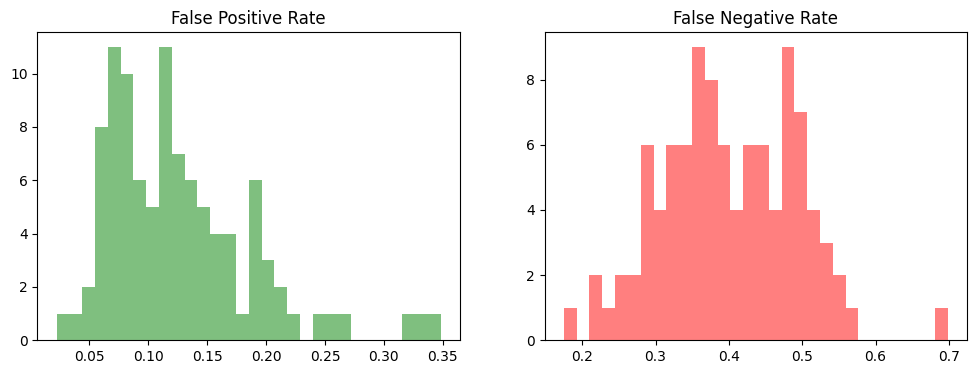

In [ ]:
data = data_SRSwR

SRSwR_FPR = data['FPR']
SRSwR_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Undersampling performance:

Error type: FPR
Mean: 0.12098666666666662
Variance: 0.0029294857912457923
Variance of estimate: 2.9294857912457923e-05
Standard error: 0.0054124724398797565
95% Confidence Interval:  [ 0.11037822068450229 ,  0.13159511264883095 ]
-----------------------------
Error type: FNR
Mean: 0.40375
Variance: 0.006528896464646462
Variance of estimate: 6.528896464646462e-05
Standard error: 0.00808015870181178
95% Confidence Interval:  [ 0.3879128889444489 ,  0.4195871110555511 ]
-----------------------------


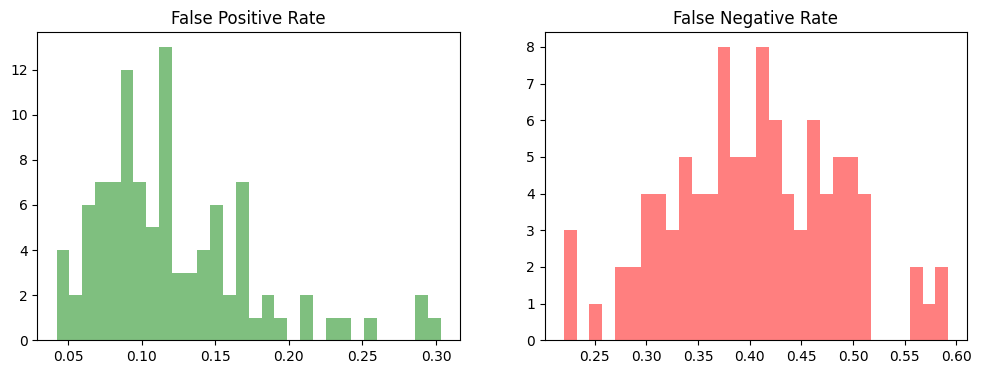

In [ ]:
data = data_Sy

Sy_FPR = data['FPR']
Sy_FNR = data['FNR']


fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Multiple Systematic Undersampling performance:

In [ ]:
data_Sy2

,Unnamed: 0,FPR,TPR,FNR,TNR
0,0,0.134000,0.628,0.372,0.866000
1,1,0.073333,0.548,0.452,0.926667
2,2,0.093000,0.596,0.404,0.907000
3,3,0.063333,0.496,0.504,0.936667
4,4,0.174333,0.690,0.310,0.825667
...,...,...,...,...,...
95,95,0.121000,0.618,0.382,0.879000
96,96,0.151333,0.664,0.336,0.848667
97,97,0.071000,0.479,0.521,0.929000
98,98,0.141333,0.663,0.337,0.858667


Error type: FPR
Mean: 0.12516333333333332
Variance: 0.0034806004377104377
Variance of estimate: 3.480600437710438e-05
Standard error: 0.00589966137817285
95% Confidence Interval:  [ 0.11359999703211454 ,  0.1367266696345521 ]
-----------------------------
Error type: FNR
Mean: 0.39297
Variance: 0.007535625353535353
Variance of estimate: 7.535625353535352e-05
Standard error: 0.008680797978029066
95% Confidence Interval:  [ 0.37595563596306303 ,  0.40998436403693694 ]
-----------------------------


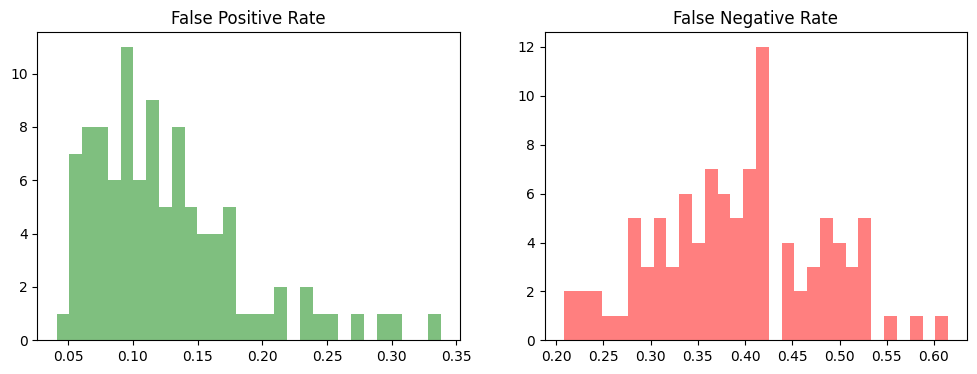

In [ ]:
data = data_Sy2

Sy2_FPR = data['FPR']
Sy2_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

## Random Oversampling (ROS):

SRS Oversampling performance:

Error type: FPR
Mean: 0.12042666668999999
Variance: 0.002484958655284041
Variance of estimate: 2.484958655284041e-05
Standard error: 0.004984935962762251
95% Confidence Interval:  [ 0.11065619220298598 ,  0.130197141177014 ]
-----------------------------
Error type: FNR
Mean: 0.33931999999999995
Variance: 0.004989795555555556
Variance of estimate: 4.989795555555557e-05
Standard error: 0.0070638484946632
95% Confidence Interval:  [ 0.3254748569504601 ,  0.35316514304953983 ]
-----------------------------


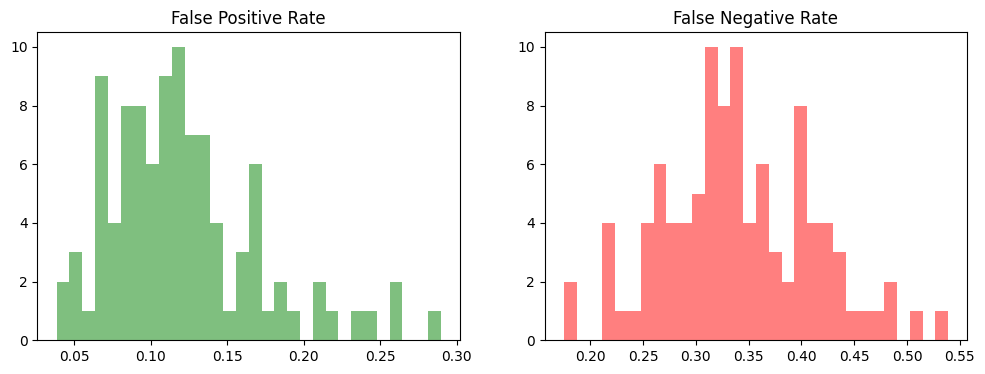

In [ ]:
data = data_SRS_ROS

SRS_ROS_FPR = data['FPR']
SRS_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Resampling performance:

In [ ]:
data_Sy_ROS

,Unnamed: 0,FPR,TPR,FNR,TNR
0,0,0.062000,0.555,0.445,0.938000
1,1,0.120000,0.700,0.300,0.880000
2,2,0.093667,0.641,0.359,0.906333
3,3,0.132000,0.714,0.286,0.868000
4,4,0.111667,0.644,0.356,0.888333
...,...,...,...,...,...
95,45,0.179667,0.718,0.282,0.820333
96,46,0.107333,0.665,0.335,0.892667
97,47,0.089667,0.619,0.381,0.910333
98,48,0.174333,0.774,0.226,0.825667


Error type: FPR
Mean: 0.11831333335
Variance: 0.0016709558218053857
Variance of estimate: 1.670955821805386e-05
Standard error: 0.004087732650021753
95% Confidence Interval:  [ 0.11030137735595735 ,  0.12632528934404263 ]
-----------------------------
Error type: FNR
Mean: 0.33977
Variance: 0.00430781525252525
Variance of estimate: 4.30781525252525e-05
Standard error: 0.006563394893289029
95% Confidence Interval:  [ 0.3269057460091535 ,  0.3526342539908465 ]
-----------------------------


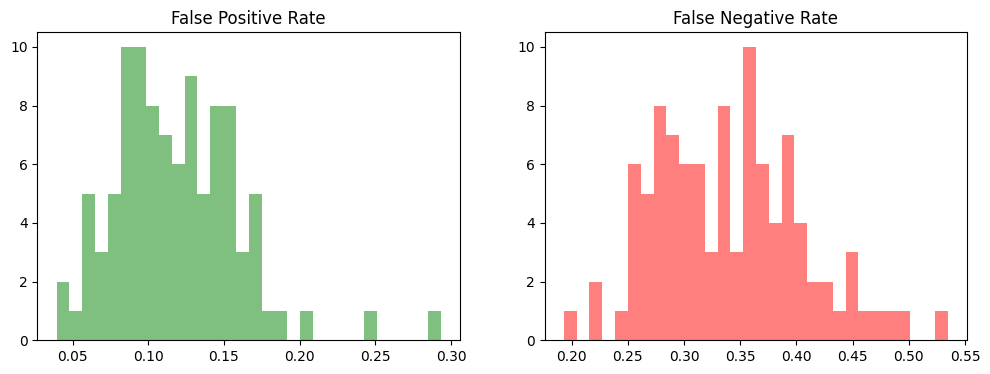

In [ ]:
data = data_Sy_ROS

Sy_ROS_FPR = data['FPR']
Sy_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

In [ ]:
FPR = pd.DataFrame()

DF = FPR


DF['SRS_RUS'] = SRS_FPR
DF['SRSwR_RUS'] = SRSwR_FPR
DF['Sy_RUS'] = Sy_FPR
DF['Sy_m_RUS'] = Sy2_FPR
DF['SRS_ROS'] = SRS_ROS_FPR
DF['Sy_ROS'] = Sy_ROS_FPR
DF['Orig'] = orig_FPR
FPR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.172667,0.133667,0.165000,0.134000,0.118667,0.062000,0.021000
1,0.085667,0.066667,0.155000,0.073333,0.156000,0.120000,0.004000
2,0.188667,0.043667,0.181667,0.093000,0.106000,0.093667,0.001333
3,0.124000,0.067333,0.090667,0.063333,0.046667,0.132000,0.004333
4,0.130000,0.133667,0.101667,0.174333,0.125667,0.111667,0.016667
...,...,...,...,...,...,...,...
95,0.114000,0.248000,0.070667,0.121000,0.115000,0.179667,NaN
96,0.187333,0.185667,0.123000,0.151333,0.090667,0.107333,NaN
97,0.056333,0.065667,0.110333,0.071000,0.187333,0.089667,NaN
98,0.154000,0.166667,0.233333,0.141333,0.101333,0.174333,NaN


<Axes: title={'center': 'FPR'}>

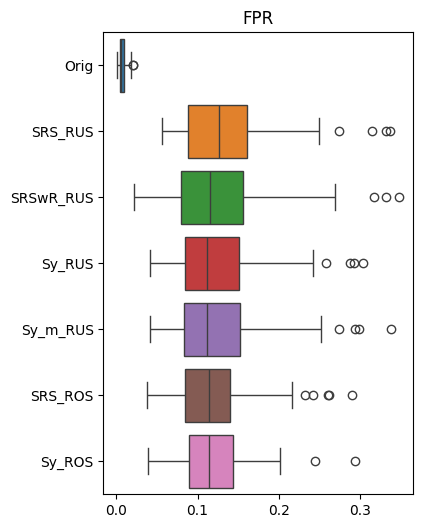

In [ ]:
dataset = FPR

plt.figure(figsize=(4,6)) #, dpi=600)
plt.title('FPR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')

In [ ]:
FNR = pd.DataFrame()

DF = FNR


DF['SRS_RUS'] = SRS_FNR
DF['SRSwR_RUS'] = SRSwR_FNR
DF['Sy_RUS'] = Sy_FNR
DF['Sy_m_RUS'] = Sy2_FNR
DF['SRS_ROS'] = SRS_ROS_FNR
DF['Sy_ROS'] = Sy_ROS_FNR
DF['Orig'] = orig_FNR
FNR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.333,0.366,0.346,0.372,0.308,0.445,0.629
1,0.465,0.484,0.336,0.452,0.271,0.300,0.855
2,0.291,0.562,0.324,0.404,0.339,0.359,0.906
3,0.453,0.497,0.437,0.504,0.485,0.286,0.828
4,0.341,0.366,0.420,0.310,0.312,0.356,0.719
...,...,...,...,...,...,...,...
95,0.387,0.284,0.502,0.382,0.336,0.282,NaN
96,0.298,0.319,0.481,0.336,0.403,0.335,NaN
97,0.519,0.526,0.407,0.521,0.238,0.381,NaN
98,0.298,0.345,0.257,0.337,0.394,0.226,NaN


<Axes: title={'center': 'FNR'}>

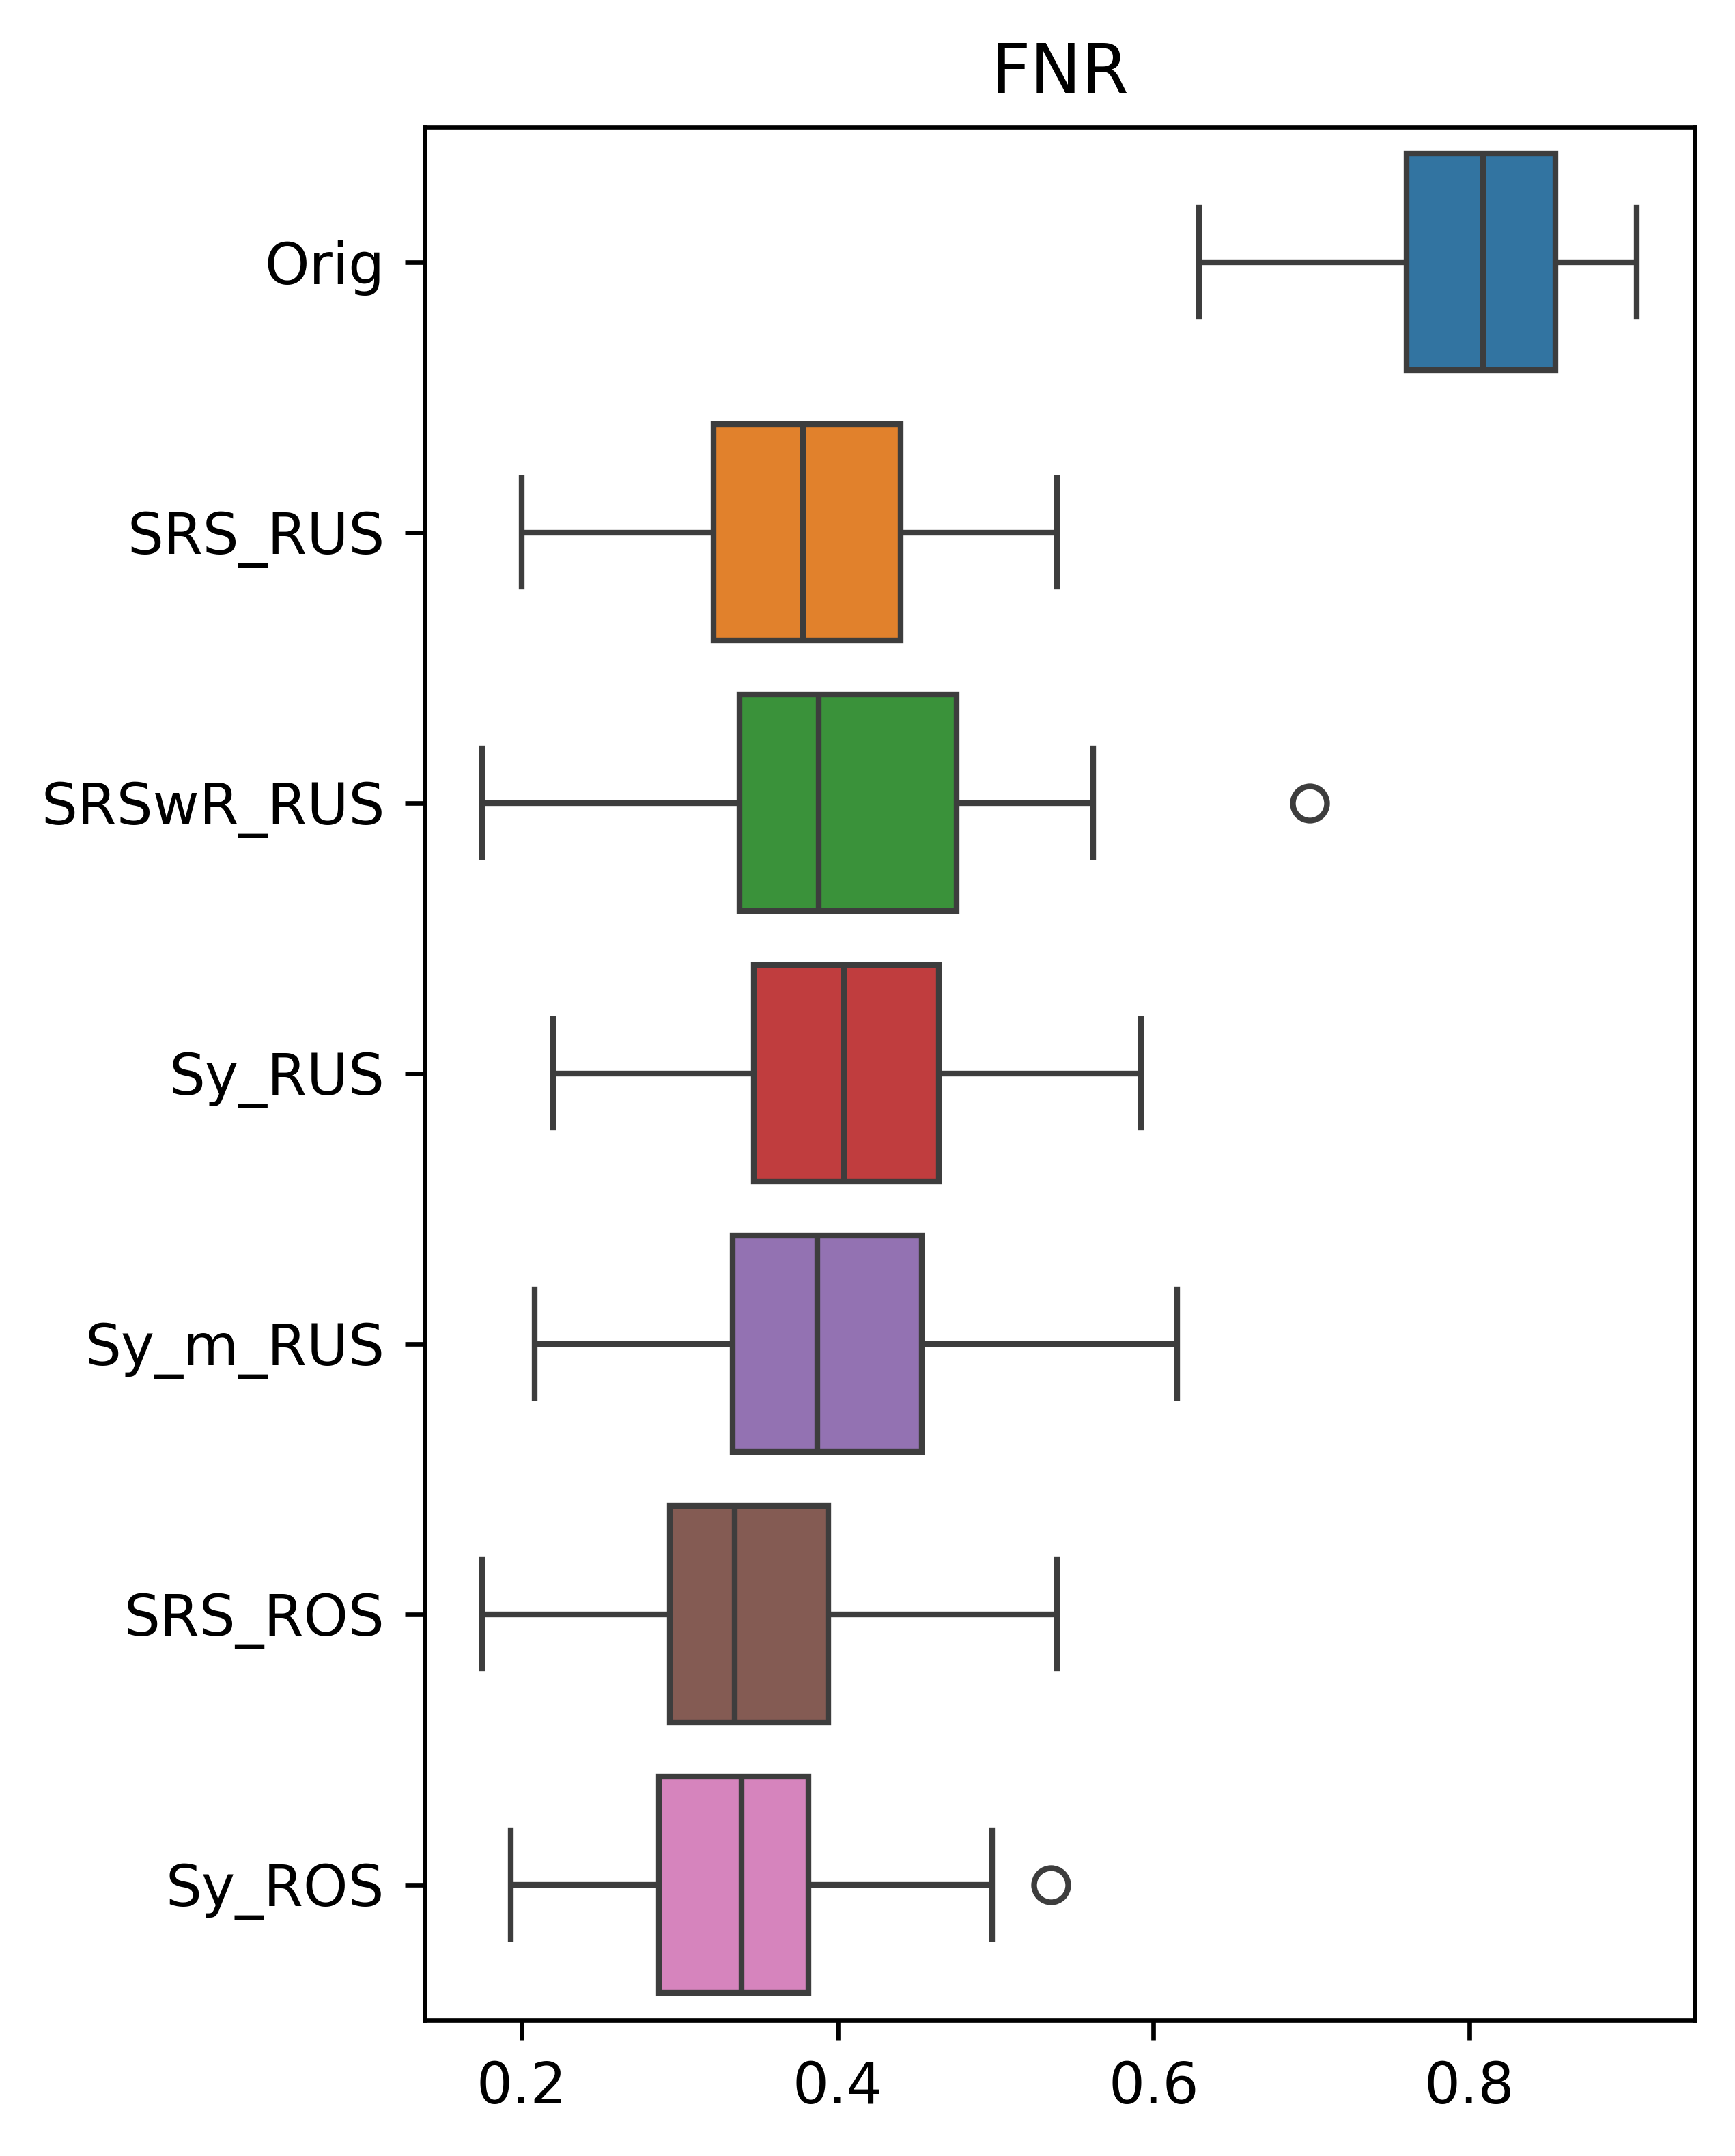

In [ ]:
dataset = FNR

plt.figure(figsize=(4,6), dpi=600)
plt.title('FNR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')